In [1]:
import numpy as np

data = np.load("Features.npz")
print(data.files) 

['Features']


In [2]:
features = data["Features"]
print(features[:2])

[[[4.89724186 2.98577437 4.95688407 7.58966539 1.95268948 8.02121963]
  [6.00879964 2.54756273 4.23606796 7.2225263  1.56653322 4.25523379]
  [4.14756949 1.54775055 3.04529355 4.90904122 2.99189628 5.27526449]
  ...
  [4.05860554 3.87486872 5.73977106 5.01372851 2.37028024 5.69184846]
  [3.48237615 2.47421658 3.67761807 6.33623876 1.63201733 4.83285121]
  [4.06071274 1.93844252 5.43481706 8.99959935 1.13039479 4.94110715]]

 [[5.16456085 3.05266153 5.2212397  6.88875775 1.92381997 8.06703362]
  [6.30567219 2.56443089 4.25987312 8.18250075 1.86506029 4.48342407]
  [4.04106117 1.80811309 3.09157977 4.56835954 3.00998302 5.12748544]
  ...
  [3.75629459 4.02426302 5.44849707 4.10045603 2.15250173 5.85166664]
  [3.68869264 2.47118778 3.72579525 6.52305644 1.36575465 5.20819206]
  [4.05561099 1.53302077 6.02203111 9.31145242 0.99809286 6.07083761]]]


In [3]:
featuresilk100 = features[:, :100, :]

In [4]:
features_son10 = features[:, 100:110, :]

In [5]:
features_min = featuresilk100.min()
features_max = featuresilk100.max()

In [6]:
features_norm = (featuresilk100 - features_min) / (features_max - features_min)

In [7]:
print("Min: {:.1f}, Max: {:.1f}".format(features_norm.min(), features_norm.max()))

Min: 0.0, Max: 1.0


In [8]:
def matcherSkorHesaplama(vektor1, vektor2):
    oklidMesafesi = np.linalg.norm(vektor1 - vektor2)
    skor = 1 / (1 + oklidMesafesi)
    return skor

In [9]:
genuineSkorlar = []

for kisi in range(100):
    for zaman1 in range(10):
        for zaman2 in range(zaman1 + 1, 10):
            vektor1 = features_norm[zaman1, kisi, :]
            vektor2 = features_norm[zaman2, kisi, :]
            skor = matcherSkorHesaplama(vektor1, vektor2)
            genuineSkorlar.append(skor)

genuineSkorlar = np.array(genuineSkorlar)
print(f"Toplam Gerçek Skor Sayısı: {len(genuineSkorlar)}")
print(f"Gerçek Skorların Ortalaması: {genuineSkorlar.mean():.3f}")


Toplam Gerçek Skor Sayısı: 4500
Gerçek Skorların Ortalaması: 0.914


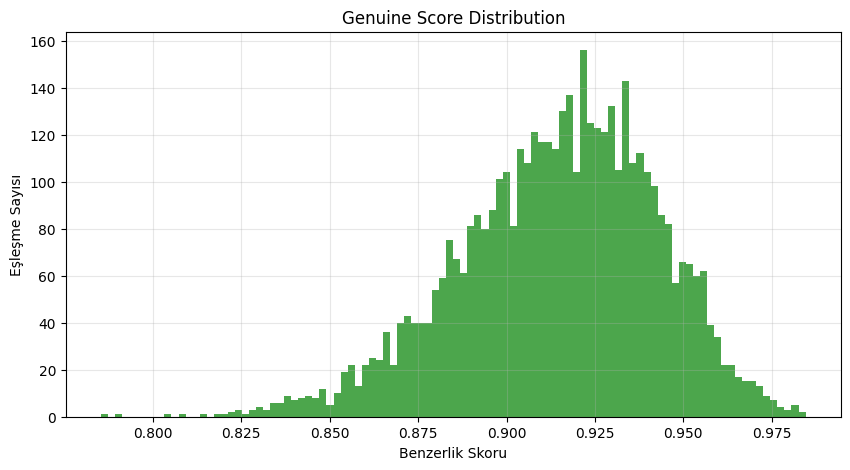

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(genuineSkorlar, bins=100, color='green', alpha=0.7)

plt.title('Genuine Score Distribution')
plt.xlabel('Benzerlik Skoru')
plt.ylabel('Eşleşme Sayısı')
plt.grid(True, alpha=0.3)

plt.show()

In [11]:
imposterSkorlar = []
for kisi1 in range(100):
    for kisi2 in range(kisi1 + 1, 100):
        for zaman1 in range(10):
            for zaman2 in range(10):
                vektor1 = features_norm[zaman1, kisi1, :]
                vektor2 = features_norm[zaman2, kisi2, :]
                skor = matcherSkorHesaplama(vektor1, vektor2)
                imposterSkorlar.append(skor)
imposterSkorlar = np.array(imposterSkorlar)
print(f"İmposter Skorların Ortalaması: {imposterSkorlar.mean():.3f}")


İmposter Skorların Ortalaması: 0.766


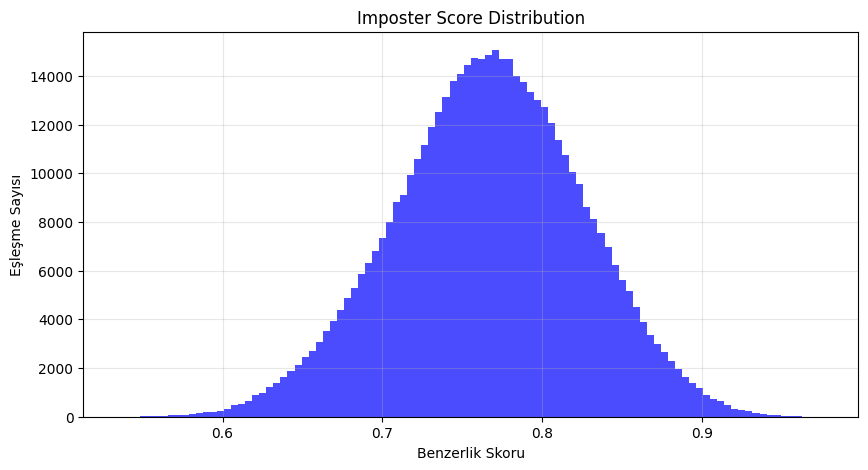

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(imposterSkorlar, bins=100, color='blue', alpha=0.7)

plt.title('Imposter Score Distribution')
plt.xlabel('Benzerlik Skoru')
plt.ylabel('Eşleşme Sayısı')
plt.grid(True, alpha=0.3)

plt.show()

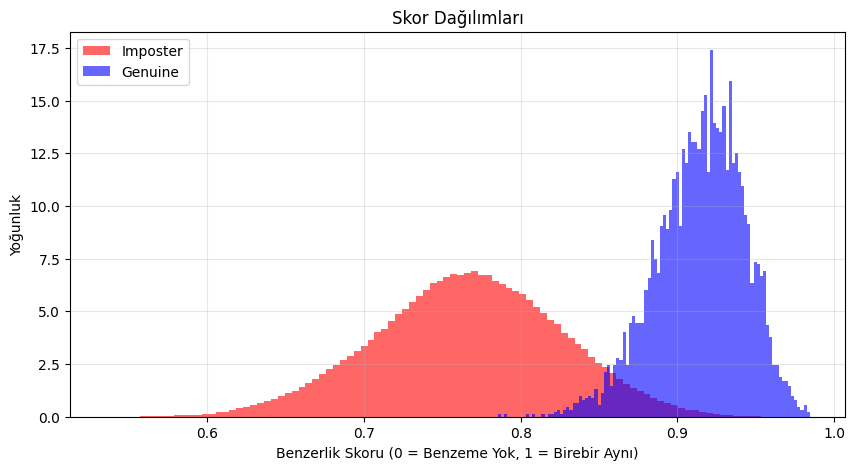

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(imposterSkorlar, bins=100, color='red', alpha=0.6, density=True, label='Imposter')
plt.hist(genuineSkorlar, bins=100, color='blue', alpha=0.6, density=True, label='Genuine')

plt.title('Skor Dağılımları')
plt.xlabel('Benzerlik Skoru (0 = Benzeme Yok, 1 = Birebir Aynı)')
plt.ylabel('Yoğunluk')

plt.legend()

plt.grid(True, alpha=0.3)
plt.show()

In [14]:
import numpy as np

esikDegerler = np.linspace(0, 1, 1000)

FAR = []

toplamSahteciSkor = len(imposterSkorlar)

for esik in esikDegerler:
   
    iceriSizanlar = np.sum(imposterSkorlar >= esik)
    farOrani = iceriSizanlar / toplamSahteciSkor
    FAR.append(farOrani)

FAR = np.array(FAR)

print(f"Eşik Değeri {esikDegerler[800]:.2f}  FAR Oranı: {FAR[800]:.4f}")

Eşik Değeri 0.80  FAR Oranı: 0.2831


In [15]:
FRR = []
toplamGercekSkor = len(genuineSkorlar)

for esik in esikDegerler:

    gecemeyenler = np.sum(genuineSkorlar < esik)
    frrOrani = gecemeyenler / toplamGercekSkor
    FRR.append(frrOrani)
    
FRR = np.array(FRR)

print(f"Eşik Değeri {esikDegerler[800]:.2f} FRR Oranı: {FRR[800]:.4f}")

Eşik Değeri 0.80 FRR Oranı: 0.0004


In [16]:
farklar = np.abs(FAR - FRR)

eer_indeksi = np.argmin(farklar)

EER = (FAR[eer_indeksi] + FRR[eer_indeksi]) / 2

eer_esik_degeri = esikDegerler[eer_indeksi]

print(f"EER: {EER:.4f}")
print(f"EER'nin sağlandığı eşik değer: {eer_esik_degeri:.4f}")

EER: 0.0464
EER'nin sağlandığı eşik değer: 0.8639


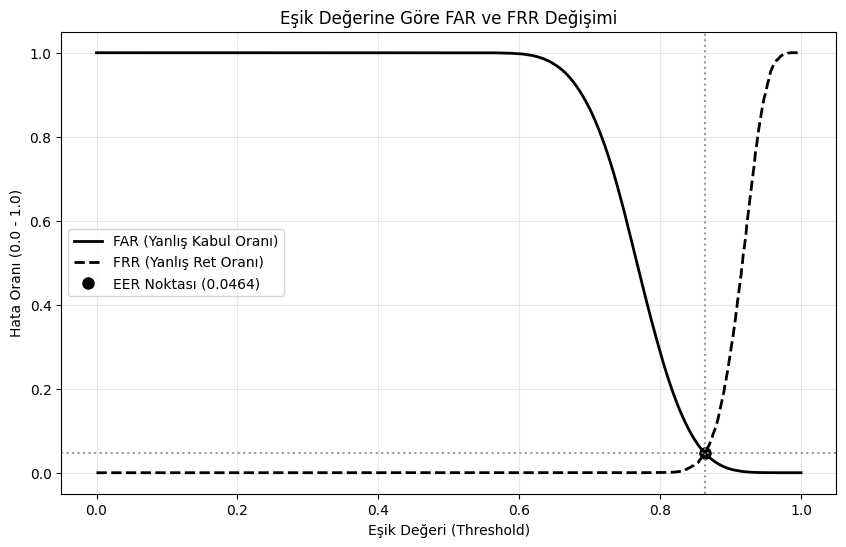

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(esikDegerler, FAR, label='FAR (Yanlış Kabul Oranı)', color='black', linestyle='-', linewidth=2)
plt.plot(esikDegerler, FRR, label='FRR (Yanlış Ret Oranı)', color='black', linestyle='--', linewidth=2)

plt.plot(eer_esik_degeri, EER, 'ko', markersize=8, label=f'EER Noktası ({EER:.4f})')

plt.axvline(x=eer_esik_degeri, color='gray', linestyle=':', alpha=0.8)
plt.axhline(y=EER, color='gray', linestyle=':', alpha=0.8)

plt.title('Eşik Değerine Göre FAR ve FRR Değişimi')
plt.xlabel('Eşik Değeri (Threshold)')
plt.ylabel('Hata Oranı (0.0 - 1.0)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

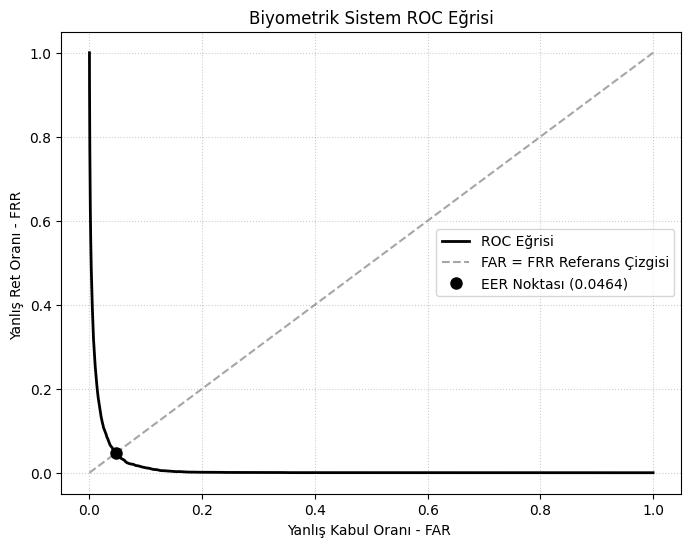

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.plot(FAR, FRR, color='black', linestyle='-', linewidth=2, label='ROC Eğrisi')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--', alpha=0.7, label='FAR = FRR Referans Çizgisi')

plt.plot(EER, EER, 'ko', markersize=8, label=f'EER Noktası ({EER:.4f})')

plt.title('Biyometrik Sistem ROC Eğrisi')
plt.xlabel('Yanlış Kabul Oranı - FAR ')
plt.ylabel('Yanlış Ret Oranı - FRR ')

plt.grid(True, alpha=0.4, color='gray', linestyle=':')
plt.legend()

plt.show()